In [1]:
import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [5]:
data_path = Path("..") / "data/engineered/training_pop40_genres.parquet"
_df = pd.read_parquet(data_path)
print(f"Loaded {len(_df):,} tracks from {data_path}")

Loaded 561,314 tracks from ../data/engineered/training_pop40_genres.parquet


# Data prep

In [6]:
from ast import literal_eval


df = _df.astype({
    "album_type": "category"
})
if pd.api.types.is_string_dtype(df["_artist_genres"]):
    df["_artist_genres"] = df["_artist_genres"].map(literal_eval)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561314 entries, 0 to 561313
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   track_rowid              561314 non-null  int64   
 1   track_name               561314 non-null  string  
 2   artist_name              561314 non-null  string  
 3   artist_rowid             561314 non-null  int64   
 4   album_rowid              561314 non-null  int64   
 5   album_name               561314 non-null  string  
 6   _label                   561314 non-null  string  
 7   artist_genres            561314 non-null  string  
 8   _artist_genres           561314 non-null  object  
 9   album_type               561314 non-null  category
 10  _time_signature_is_four  561314 non-null  bool    
 11  _key_cos                 561314 non-null  float32 
 12  _key_sin                 561314 non-null  float32 
 13  mode                     561314 non-null  bo

##  Indexing Genres

In [8]:
from ast import literal_eval

def build_genre_vocab(genres: pd.Series):
    vocab = {}
    for genres in genres:
        for genre in genres:
            if genre not in vocab:
                vocab[genre] = len(vocab)
    return vocab

genre2idx = build_genre_vocab(df["_artist_genres"])
print(f"Found {len(genre2idx)} genres.")

Found 647 genres.


In [9]:
def build_label_vocab(labels: pd.Series):
    vocab = {}
    for label in labels.value_counts().index:
        if label not in vocab:
            vocab[label] = len(vocab)
    return vocab

label2idx = build_label_vocab(df["_label"])
print(f"Found {len(label2idx)} unique labels.")

Found 3257 unique labels.


## Train split

We split selecting artists at random to minimize data leakage from duplicate tracks.

In [10]:
np.random.seed(0)

artists_unique = df["artist_rowid"].unique()
nartists_train = int(0.9 * len(artists_unique))
artists_train = np.random.choice(artists_unique, replace=False, size=nartists_train)

_shuffled = df.sample(frac=1, replace=False, ignore_index=True, random_state=0)
train_mask = _shuffled["artist_rowid"].isin(artists_train)
dft = _shuffled[train_mask].reset_index(drop=True)
dfv = _shuffled[~train_mask].reset_index(drop=True)

print(f"train amounts to {100 * len(dft) / len(df):.1f} % of the dataset")

train amounts to 90.1 % of the dataset


## Standardizing numerical features

In [11]:
df.select_dtypes(include=np.number).columns

Index(['track_rowid', 'artist_rowid', 'album_rowid', '_key_cos', '_key_sin',
       'tempo', '_release_year', '_release_yday_cos', '_release_yday_sin',
       'danceability', 'energy', '_loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'duration_ms'],
      dtype='object')

In [12]:
def minmax(s: pd.Series, r: pd.Series | None=None, vrange:tuple[int, int]=(0, 1)) -> pd.Series:
    if r is None:
        r = s
    a, b = vrange
    return a + (s - r.min()) * (b - a) / (r.max() - r.min())

def zscore(s: pd.Series, r: pd.Series | None=None, mode: str = "mean"):
    if r is None:
        r = s
    if mode == "mean":
        m = r.mean()
    elif mode == "median":
        m = r.median()
    else:
        raise ValueError()
    return (s - m) / r.std()


ZSCORE_COLS = ["tempo", "duration_ms", "danceability", "energy", "_loudness", "liveness", "valence"]
MINMAX_COLS = ["_release_year", "speechiness", "acousticness", "instrumentalness"]

for col in ZSCORE_COLS:
  dfv[col] = zscore(dfv[col], dft[col], mode="median")
  dft[col] = zscore(dft[col], mode="median")

for col in MINMAX_COLS:
  dfv[col] = minmax(dfv[col], dft[col], vrange=(-1., 1.))
  dft[col] = minmax(dft[col], vrange=(-1., 1.))

In [13]:
if (_plot_train_correlations := False):
    features = [
        "tempo", "duration_ms", "_release_year", "danceability", "energy",
        "_loudness", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence",
    ]
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, n_feat, figsize=(12,12))
    
    for i in range(n_feat):
        for j in range(n_feat):
            ax = axes[i, j]
            if i == j:
                ax.hist(dft[features[i]], bins=30, color='steelblue', edgecolor='white')
            else:
                ax.hist2d(dft[features[j]], dft[features[i]], bins=30)
            
            if i == n_feat - 1:
                ax.set_xlabel(features[j], rotation=45, ha='right')
                ax.tick_params(axis='x', labelsize=7, rotation=45)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(features[i])
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Dataset

In [14]:
import torch
from torch.utils.data import Dataset
from torch.nn.functional import one_hot


class TrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, label2idx: dict[str, int], genre2idx: dict[str, int], num_atypes: int):
        # for training
        self.label = torch.tensor(df["_label"].map(label2idx).values, dtype=torch.long)
        # genres multi-hot
        self.genres = torch.zeros(len(df), len(genre2idx), dtype=torch.float32) # float32, it will feed a layer embedding
        for i, gs in enumerate(df["_artist_genres"]):
            for g in gs:
                self.genres[i, genre2idx[g]] = 1.
        # float variables
        self.numeric = torch.cat(
            (
                one_hot(
                    torch.tensor(df["album_type"].cat.codes.values, dtype=torch.long), 
                    num_classes=num_atypes,
                ),
                torch.tensor(
                    df[[
                        "_release_year",
                        "_release_yday_cos",
                        "_release_yday_sin",
                        "_key_cos", 
                        "_key_sin",
                        "mode",
                        "tempo",
                        "_time_signature_is_four",
                        "danceability",
                        "energy",
                        "_loudness",
                        "speechiness",
                        "acousticness",
                        "instrumentalness",
                        "liveness",
                        "valence",
                        "explicit",
                        "duration_ms",
                    ]].values.astype(float), 
                    dtype=torch.float32
                ),
            ), dim=1,
        )
        self._len = len(df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        return (
            self.label[idx],
            self.genres[idx],
            self.numeric[idx],
        )

def collate_fn(batch):
    label, genres, numeric = zip(*batch)
    return {
        # "label": torch.stack(label),
        "genres": torch.stack(genres),
        "numeric": torch.stack(numeric),
    }


In [15]:
import torch
from torch import nn

class TrackAutoencoder(nn.Module):
    DIM_HIDDEN1 = 1024
    DIM_HIDDEN2 = 216
    DIM_HIDDEN3 = 64
    DIM_LATENT = 32
    DIM_GENRE_EMBEDDING = 32

    DROPOUT = 0.3
    LEAKY_RELU = 0.1

    def __init__(
        self,
        ngenres: int,
        nnumeric: int,
    ):
        super().__init__()
        self.genre_embedding = nn.Sequential(
            nn.Linear(ngenres, self.DIM_GENRE_EMBEDDING),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
        )
        dim_in = nnumeric + self.DIM_GENRE_EMBEDDING

        self.encoder = nn.Sequential(
            nn.Linear(dim_in, self.DIM_HIDDEN1),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN1, self.DIM_HIDDEN2),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN3),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_LATENT),
        )
        self._decoder = nn.Sequential(
            nn.Linear(self.DIM_LATENT, self.DIM_HIDDEN3),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_HIDDEN2),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN1),
            nn.LeakyReLU(self.LEAKY_RELU),
        )
        self.head_genres = nn.Linear(self.DIM_HIDDEN1, ngenres)
        self.head_numeric = nn.Linear(self.DIM_HIDDEN1, nnumeric)

    def embed(self, batch: dict[torch.Tensor]) -> torch.Tensor:
        return torch.cat((
            self.genre_embedding(batch["genres"]),
            batch["numeric"],
        ), dim=1)

    def encode(self, batch: dict) -> torch.Tensor:
        return self.encoder(self.embed(batch))
        
    def forward(self, batch: dict):
        zs = self._decoder(self.encode(batch))
        return {
            "genres": self.head_genres(zs),
            "numeric": self.head_numeric(zs),  
        }

# Loss

In [16]:
from typing import Callable

def get_loss(weights=None) -> Callable:
    bce = nn.BCEWithLogitsLoss()
    mse = nn.MSELoss()

    keys = ["genres", "numeric"]
    if weights is None:
        weights = {}
    elif any([k not in keys for k in weights]):
        raise ValueError(f"Wrong key for weights. Allowed keys are: {', '.join(keys)}")
    weights |= {k: 1.0 for k in keys if k not in weights}

    def compute_batch_loss(predictions, targets) -> dict:
        l_genres = bce(predictions["genres"], targets["genres"])
        l_numeric = mse(predictions["numeric"], targets["numeric"])
        total = (
            l_numeric * weights["numeric"] +
            l_genres * weights["genres"]
        ) / sum(weights.values())
        return {
            "total": total,
            "numeric": l_numeric.item(),
            "genres": l_genres.item(),
        }
    
    return compute_batch_loss, keys

# Training

In [17]:
from torch.utils.data import DataLoader
from torch import optim


print("Creating dataloaders..")
train_dataset = TrackDataset(dft, label2idx, genre2idx, len(df["album_type"].cat.categories))
valid_dataset = TrackDataset(dfv, label2idx, genre2idx, len(df["album_type"].cat.categories))
train = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=20, pin_memory=True, collate_fn=collate_fn)
valid = DataLoader(valid_dataset, batch_size=512, num_workers=20, pin_memory=True, collate_fn=collate_fn)

Creating dataloaders..


In [18]:
model = TrackAutoencoder(
    ngenres=len(genre2idx),
    nnumeric=train_dataset.numeric.shape[1],
)
device = torch.device("cuda")
model = model.to(device)

In [21]:
import time
torch.set_float32_matmul_precision('medium')

def log_epoch(epoch, t, train_metrics, valid_metrics):
    print(f"\n{'='*20} EPOCH {epoch:02d} (Time: {t:.2f}s) {'='*20}")
    
    header = f"{'Metric':<15} | {'Train':<10} | {'Valid':<10}"
    print(header)
    print("-" * len(header))
    
    for key in train_metrics.keys():
        t_val = train_metrics[key]
        v_val = valid_metrics[key]
        print(f"{key.replace('_', ' ').title():<15} | {t_val:<10.5f} | {v_val:<10.5f}")    


print("Initializing model..")
NEPOCHS, LR = 20, 1e-4
history = []
model = TrackAutoencoder(
    ngenres=len(genre2idx),
    nnumeric=train_dataset.numeric.shape[1],
)
device = torch.device("cuda")
model = model.to(device)
model.compile()
compute_loss, loss_keys = get_loss(weights={"numeric": 1., "genres": .5})
optimizer = optim.Adam(model.parameters(), lr=LR)

t0 = time.time()
print(f"Training on {len(train_dataset)} rows..")
for epoch in range(NEPOCHS):
    model.train()
    train_metrics = {k: 0.0 for k in loss_keys}
    
    for batch in train:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        xs = model(batch)
        batch_loss = compute_loss(xs, batch)
        batch_loss["total"].backward()
        optimizer.step()
        
        for k in train_metrics.keys():
            val = batch_loss[k]
            train_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
            
    model.eval()
    valid_metrics = {k: 0.0 for k in loss_keys}
    with torch.no_grad():
        for batch in valid:
            batch = {k: v.to(device) for k, v in batch.items()}
            xs = model(batch)
            batch_loss = compute_loss(xs, batch)
            
            for k in valid_metrics.keys():
                val = batch_loss[k]
                valid_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
                
    if epoch % (PRINT_EVERY := 1) == 0:
        # print(f"Epoch {epoch}, Train Loss: {history[-1][0]:.4f}, Valid Loss: {history[-1][1]:.4f} (LRf: {(_lrf := scheduler.get_last_lr()[0] / LR):.3f})")
        avg_train = {k: v / len(train) for k, v in train_metrics.items()}
        avg_valid = {k: v / len(valid) for k, v in valid_metrics.items()}
        
        log_epoch(epoch, time.time() - t0, avg_train, avg_valid)
        history.append((avg_train, avg_valid))

Initializing model..
Training on 506002 rows..


W0207 21:46:42.743000 4514 torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode



==================== EPOCH 00 (Time: 11.64s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Genres          | 0.06176    | 0.01844   
Numeric         | 0.23374    | 0.07591   

==================== EPOCH 01 (Time: 16.19s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Genres          | 0.01846    | 0.01668   
Numeric         | 0.10797    | 0.04951   

==================== EPOCH 02 (Time: 21.14s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Genres          | 0.01663    | 0.01560   
Numeric         | 0.09065    | 0.04219   

==================== EPOCH 03 (Time: 26.22s) ====================
Metric          | Train      | Valid     
-----------------------------------------
Genres          | 0.01574    | 0.01507   
Numeric         | 0.08005    | 0.03521   

==================== EPOCH 04 (Time: 30.82s) ==============

# Profiling

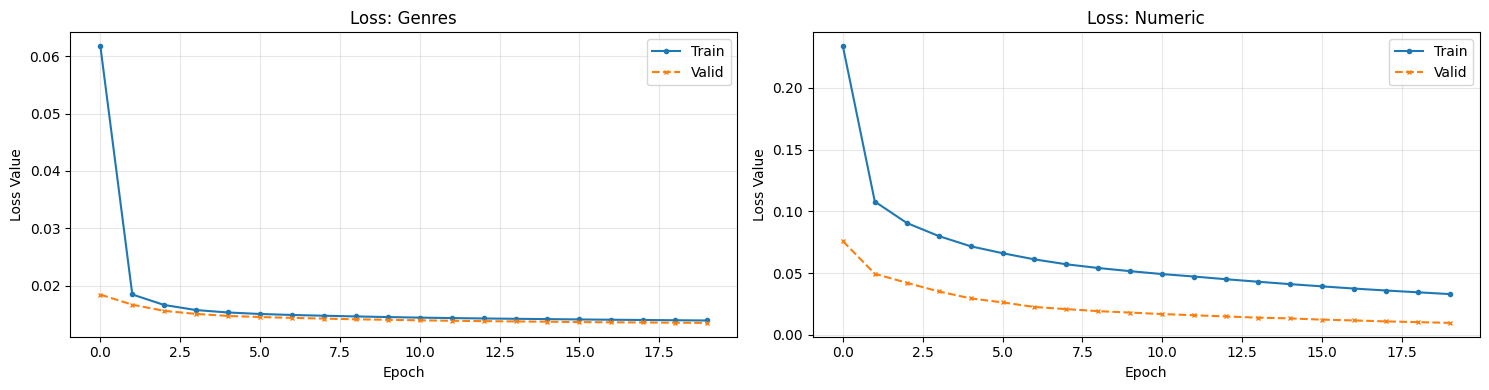

In [22]:
import matplotlib.pyplot as plt


def plot_training_results(history):
    metrics = list(history[0][0].keys())
    num_metrics = len(metrics)
    
    cols = 2
    rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        train_vals = [h[0][metric] for h in history]
        valid_vals = [h[1][metric] for h in history]
        
        ax = axes[i]
        ax.plot(train_vals, label="Train", marker="o", markersize=3)
        ax.plot(valid_vals, label="Valid", linestyle="--", marker="x", markersize=3)
        
        title = metric.replace("_", " ").title()
        ax.set_title(f"Loss: {title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")
        ax.legend()
        ax.grid(True, alpha=0.3)
        if train_vals[0] / (train_vals[-1] + 1e-9) > 100:
            ax.set_yscale("log")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Use it like this:
plot_training_results(history)

In [51]:
import torch.nn.functional as F


def get_recommender(
    model: nn.Module, 
    device: torch.device, 
    df: pd.DataFrame, 
    label2idx: dict, 
    genre2idx: dict, 
    num_atypes: int,
):
    embeddings = [None]
    
    @torch.no_grad()
    def get_all_embeddings():
        dataset = TrackDataset(df, label2idx, genre2idx, num_atypes)
        dl = DataLoader(dataset, batch_size=1024, shuffle=False, num_workers=20, collate_fn=collate_fn)
        ys = []
        model.eval()
        for batch in dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            ys.append(model.encode(batch))
        return torch.cat(ys, dim=0)

    def recommend(artist: str, track: str, n=10):
        match = df[(df["artist_name"] == artist) & (df["track_name"] == track)]
        if match.empty: 
            return "Track not found."
        idx = match.index[0]
        query_vec = Z[idx].unsqueeze(0)
        sim = F.cosine_similarity(query_vec, Z)
        scores, top_indices = torch.topk(sim, k=n+1)
        similiar_df = df.iloc[top_indices[1:].cpu()]
        return pd.DataFrame({
            "artist_name": similiar_df["artist_name"],
            "track_name": similiar_df["track_name"],
            "score": scores.cpu()[1:],
        })
        
    Z = get_all_embeddings()        
    return recommend

recommend = get_recommender(model, device, dft, label2idx, genre2idx, 3)

In [60]:
recommend("MF DOOM", "Hoe Cakes", 10)

,artist_name,track_name,score
228944,Marc E. Bassy,Plot Twist,0.967061
224192,BERNA,Nuttin New,0.947380
342620,Marc E. Bassy,You & Me,0.936555
399589,J. Cole,Can I Live,0.934833
304095,Ludacris,Runaway Love,0.930954
91804,MF DOOM,Hey!,0.925844
164755,Westside Gunn,"Celine Dion (feat. Heem, Chase Fetti & Flee Lord)",0.921078
153501,Spice 1,I Got Five On It Remix,0.920973
503483,T.O.K,Money 2 Burn,0.920261
457257,Mavins,Alle,0.917195
